#  Introduction to the surface code

- **Author**: Théo HUET
- **Date**: 18/09/2026

Implementation and Verification of a $d=3$ Planar Surface Code using **Qiskit**.

The objective of this notebook is to implement a distance-3 ($d=3$) planar surface code to encode $1$ logical qubit using $17$ physical qubits ($9$ data qubits and $8$ ancilla qubits for measurement). Drawing on the theoretical framework from Cleland's "An introduction to the surface code", the goal is to successfully initialize a logical state (e.g., $\vert{}0\rangle_L$), artificially inject single-qubit Pauli errors (Bit-flip $X$, Phase-flip $Z$, or both $Y$) on targeted data qubits, and extract the error syndrome via non-destructive parity measurements of the $X$-stabilizer and $Z$-stabilizer plaquettes. Finally, the notebook will implement a classical decoding routine (Look-up Table) to map the extracted syndrome to the most probable physical error, apply the corresponding correction, and verify the perfect preservation of the logical quantum state.

In [1]:
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

In [2]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

---

# 1. Extraction d'un stabilisateur Z1 Z2

Circuit Stabilisateur Z


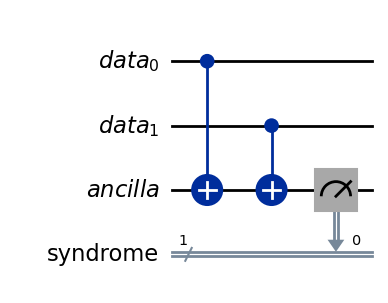

In [7]:
# On définit 2 qubits de données (d0, d1) et 1 qubit ancillaire (a0)
q_data_z = QuantumRegister(2, name="data")
q_anc_z = QuantumRegister(1, name="ancilla")
c_syndrome_z = ClassicalRegister(1, name="syndrome") #classic bit

qc_z_stab = QuantumCircuit(q_data_z, q_anc_z, c_syndrome_z, name="Circuit Stabilisateur Z")

# (Optionnel) On peut injecter une erreur Pauli X sur data[0] pour tester
# qc_z_stab.x(q_data_z[0])

# Circuit de mesure du stabilisateur Z0 Z1 :
# CNOT(data_0 -> ancilla), CNOT(data_1 -> ancilla)
qc_z_stab.cx(q_data_z[0], q_anc_z[0])
qc_z_stab.cx(q_data_z[1], q_anc_z[0])
qc_z_stab.measure(q_anc_z[0], c_syndrome_z[0])

print(qc_z_stab.name)
qc_z_stab.draw(output="mpl", style="iqp")


# 2. Extraction d'un stabilisateur X1 X2

Circuit Stabilisateur X


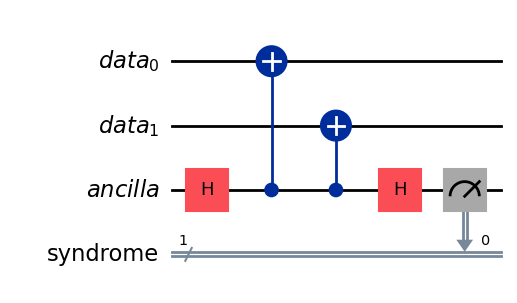

In [10]:
q_data_x = QuantumRegister(2, name="data")
q_anc_x = QuantumRegister(1, name="ancilla")
c_syndrome_x = ClassicalRegister(1, name="syndrome")

qc_x_stab = QuantumCircuit(q_data_x, q_anc_x, c_syndrome_x, name="Circuit Stabilisateur X")

# Circuit de mesure du stabilisateur X0 X1 :
# On passe dans la base X avec Hadamard sur l'ancillaire
qc_x_stab.h(q_anc_x[0])
qc_x_stab.cx(q_anc_x[0], q_data_x[0])
qc_x_stab.cx(q_anc_x[0], q_data_x[1])
qc_x_stab.h(q_anc_x[0])
qc_x_stab.measure(q_anc_x[0], c_syndrome_x[0])

print(qc_x_stab.name)
qc_x_stab.draw(output="mpl", style="iqp")

In [5]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

---

## References

- **An introduction to the surface code**
Andrew N. Cleland
*University of Chicago, Chicago IL 60637, USA*
(SciPost Phys. Lect. Notes 49 (2022) · published 3 May 2022 )

- Yunos EL KADERI's course on **Quantum Computation and Error-Control Codes** (Master 2)

- [IBM Qiskit documentation](https://quantum.cloud.ibm.com/docs/en/guides)

- [Numpy documentation](https://numpy.org/doc/)

- [Matplotlib documentation](https://matplotlib.org/stable/index.html)